Columns: ['Wavelength', 'Diatom_Ptricornutum', 'Diatom_Csimplex', 'Chlamydomonas_Cpriscuii', 'Chlamydomonas_Creindhardtii', 'Dinoflagellate_Symbiodiniumsp', 'Dinoflagellate_Smicroadriaticum', 'Dinoflagellate_Dtrenchii', 'Dinoflagellate_Cgoreaui', 'Cyanobacteria_Synechosystis']
   Wavelength  Diatom_Ptricornutum  Diatom_Csimplex  Chlamydomonas_Cpriscuii  \
0         800                  0.0              0.0                      0.0   
1         799                  0.0              0.0                      0.0   
2         798                  0.0              0.0                      0.0   
3         797                  0.0              0.0                      0.0   
4         796                  0.0              0.0                      0.0   

   Chlamydomonas_Creindhardtii  Dinoflagellate_Symbiodiniumsp  \
0                          0.0                      -0.000045   
1                          0.0                       0.004540   
2                          0.0                

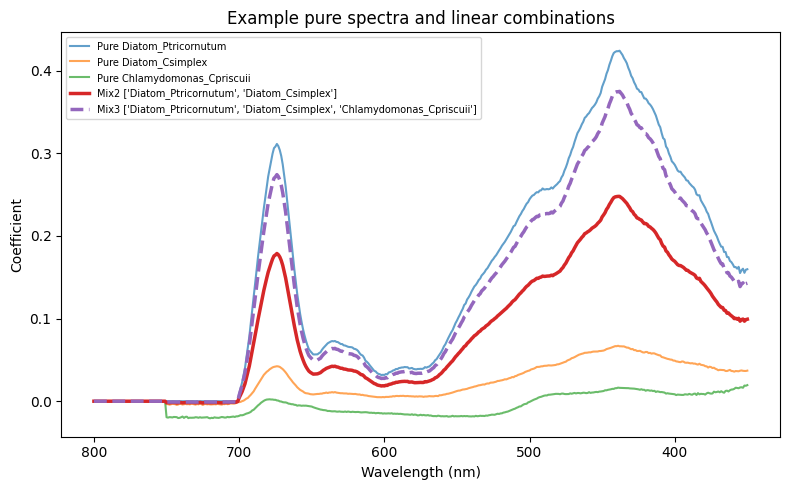

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from linear_combination import generate_mixture_spectra
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture


# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12

In [3]:
df = pd.read_excel('Spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs

wavelength = df['Wavelength']
abs_spectra = df.iloc[:, 1:].to_numpy().T

# for spectrum in abs_spectra:
#     plt.plot(wavelength, spectrum)
# plt.show()

In [4]:
def data_creation(N_training_, N_validation_, noise_level_, abs_spectra_):
    # set seed for reproduction purposes
    N_species = len(abs_spectra_)
    N_wavelengths = len(wavelength)
    X = torch.zeros(N_species, (N_training_ + N_validation_), N_wavelengths)
    y = torch.zeros(N_species, (N_training_ + N_validation_), dtype=torch.long) # class needs integer 

    for specie_index, spectra in enumerate(abs_spectra_):
        data = torch.zeros(N_training_ + N_validation_, N_wavelengths)
        
        for i in range(N_training_ + N_validation_):
            data[i, :] = torch.tensor(spectra, dtype=torch.float32) + noise_level_ * torch.randn(N_wavelengths)

        X[specie_index] = data
        y[specie_index] = torch.zeros(N_training_ + N_validation_, dtype=torch.long) + int(specie_index)

    # shuffle first
    perm = torch.randperm(X.shape[1])
    X, y = X[:, perm, :], y[:, perm]
    
    # compute stats on training portion only
    mean = X[:, :N_training_, :].mean(dim=(1,2), keepdim=True)
    std  = X[:, :N_training_, :].std(dim=(1,2),  keepdim=True) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets into training and validation
    X_train_, y_train_ = X_norm[:, :N_training_, :], y[:, :N_training_]
    X_val_,   y_val_   = X_norm[:, N_training_:, :], y[:, N_training_:]
    return X_train_, y_train_, X_val_, y_val_

In [ ]:
noise_level = .1
X_train, y_train, X_val, y_val = data_creation(400, 80, noise_level, abs_spectra)
N_species, N_train, N_wave = X_train.shape

# Sample dimensions (N_species, N_train, N_wave) ==> (N_samples_total, N_wave)
X_pure = X_train.reshape(-1, N_wave).numpy()

# Sample dimensions (N_species, N_train) ==> (N_samples_total)
y_pure = y_train.reshape(-1).numpy()

torch.Size([9, 400])


In [43]:
# PCA implementation
pca = PCA(n_components=10, random_state=0)
pca.fit(X_pure)

# All pure spectra in PCA space
X_pure_pca = pca.fit_transform(X_pure)

# Gaussian Mixture Model implementation
gmm = GaussianMixture(
    n_components=N_species,
    n_init=10,
    random_state=0
)

gmm.fit(X_pure_pca)

# Mapping sklearn components to species labels
resp_pure = gmm.predict_proba(X_pure_pca)   # Shape: (N_samples, N_species)
component_to_species = {}
for k in range(N_species):
    # Find all samples whose most likely component is k
    idx = np.argmax(resp_pure, axis=1) == k

    # The model can't tell which species is best (bad)
    if idx.sum() == 0:
        component_to_species[k] = None

    else:
        labels = y_pure[idx]
        values, counts = np.unique(labels, return_counts=True)

        # Pick the majority species among those samples (for example, k=3 is mapped to species 0)
        component_to_species[k] = int(values[np.argmax(counts)])

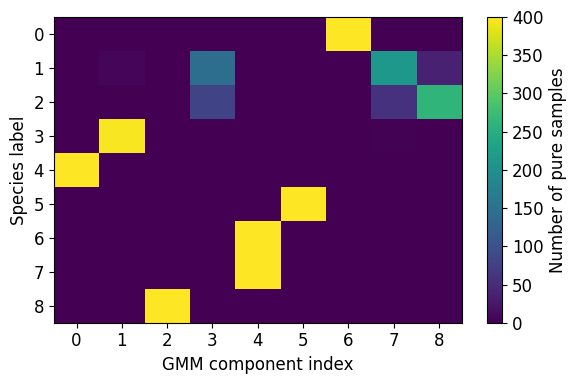

In [44]:
comp_hat = np.argmax(resp_pure, axis=1)
species_ids = np.unique(y_pure)
component_ids = np.arange(resp_pure.shape[1])

counts = np.zeros((len(species_ids), len(component_ids)), dtype=int)

for i, s in enumerate(species_ids):
    for j, k in enumerate(component_ids):
        counts[i, j] = np.sum((y_pure == s) & (comp_hat == k))

plt.figure(figsize=(6, 4))
im = plt.imshow(counts, aspect='auto', cmap='viridis')
plt.colorbar(im, label="Number of pure samples")

plt.xticks(ticks=np.arange(len(component_ids)), labels=component_ids)
plt.yticks(ticks=np.arange(len(species_ids)), labels=species_ids)

plt.xlabel("GMM component index")
plt.ylabel("Species label")
plt.tight_layout()
plt.show()

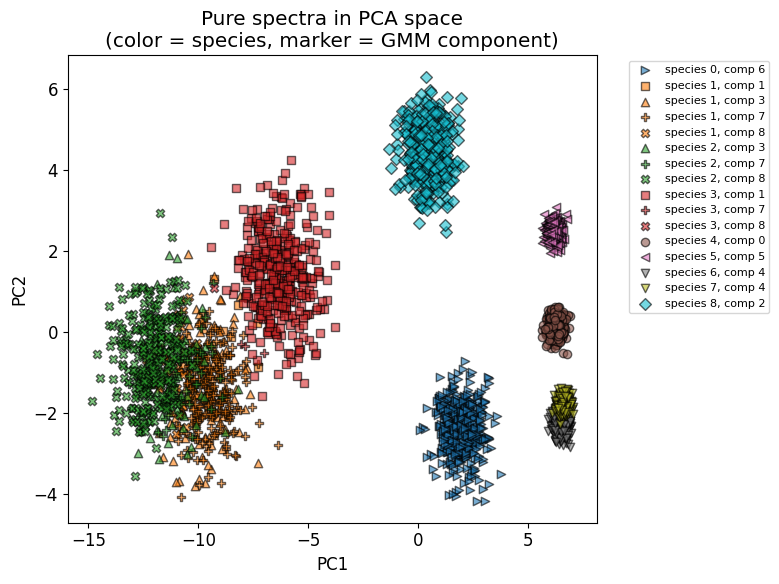

In [45]:
pc1 = X_pure_pca[:, 0]
pc2 = X_pure_pca[:, 1]

# For each sample: component with max responsibility
comp_hat = np.argmax(resp_pure, axis=1)

n_species = len(np.unique(y_pure))
n_components = resp_pure.shape[1]

plt.figure(figsize=(8, 6))

# Color by true species, marker style by component
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X']
colors = plt.cm.tab10(np.linspace(0, 1, n_species))

for s in range(n_species):
    for k in range(n_components):
        mask = (y_pure == s) & (comp_hat == k)
        if not np.any(mask):
            continue
        label = f"species {s}, comp {k}"
        plt.scatter(
            pc1[mask], pc2[mask],
            c=[colors[s]],
            marker=markers[k % len(markers)],
            edgecolor='k',
            alpha=0.6,
            label=label
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pure spectra in PCA space\n(color = species, marker = GMM component)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Small explanation on mapping for intuition
After training (`gmm.fit(X_pure_pca)`), `sklearn` gives you component indexed as `0, 1, 2, ...`, but it does not know which GMM component corresponds to which species. Therefore, we need to map these components to species labels (hence why I choose to use `n_components=N_species` in the `GaussianMixture` class). As an example: resp_pure[i, k] is approximately the probability that sample i belongs to component k. Consequently, each (mixed) sample must sum to 1.

$$
\sum_{k=0}^{N_{\text{species}} - 1} \text{resp\_pure}(i, k) = 1
$$

Then, the code looks among the species component k likes best. It asks itself which species occurs most often (majority species); that species belongs to that component!

In [5]:
def training_loop(nr_epochs, epochs_no_improvement, X_train_, y_train_, X_val_, y_val_):
    N_species = len(y_val_)
    model_1 = nn.Sequential(
    nn.Linear(len(wavelength), 64),
    nn.ReLU(),
    nn.Linear(64, N_species)
    )
    model_2 = nn.Sequential(
    nn.Linear(len(wavelength), 64),
    nn.ReLU(),
    nn.Linear(64, 16),
    nn.ReLU(),
    nn.Linear(16, N_species)
    )
    model_3 = nn.Sequential(
    nn.Linear(len(wavelength), 128),
    nn.ReLU(),
    nn.Linear(128, N_species)
    )

    model = model_3
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # changes learning rate for better learning
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor = 0.5, min_lr = 1e-6)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs   = []
    epochs_list = []

    X_train_ = X_train_.reshape(-1, len(wavelength))        # (9*200, 451) = (1800, 451)
    X_val_ = X_val_.reshape(-1,len(wavelength))
    y_train_ = y_train_.reshape(-1)           # (1800,)
    y_val_ = y_val_.reshape(-1)

    best_val_loss = float('inf')

    for epoch in range(nr_epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_).squeeze()
        
        # input should be (Ntraining * Nclasses, Nwavelength)
        loss = nn.CrossEntropyLoss()(pred[:, :], y_train_)
        loss.backward()
        optimizer.step()

        # find probability of logit (pred)
        prob = nn.Softmax(dim=1)(pred)
        class_choice = torch.argmax(prob, dim = 1)

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_).squeeze() # same shape as y_val
            loss_val = nn.CrossEntropyLoss()(pred_val[:], y_val_)

            prob_val = nn.Softmax(dim=1)(pred_val)
            class_choice_val = torch.argmax(prob_val, dim = 1)
            
        # if true, we return a 1. Else 0.
        train_acc = (class_choice == y_train_).float().mean().item() * 100
        val_acc = (class_choice_val == y_val_).float().mean().item() * 100


        train_losses.append(loss.item())
        val_losses.append(loss_val.item()) 
        train_accs.append(train_acc)
        val_accs.append(val_acc) 
        epochs_list.append(epoch)

        # if validation loss grows, break loop
        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= epochs_no_improvement:
            print(f"Early stopping at epoch {epoch}")
            break
        scheduler.step(loss_val.item())
    return train_losses, val_losses, train_accs, val_accs, epochs_list, model


In [6]:
train_losses, val_losses, train_accs, val_accs, epochs_list, trained_model = training_loop(400, 1, X_train, y_train, X_val, y_val)

Early stopping at epoch 122


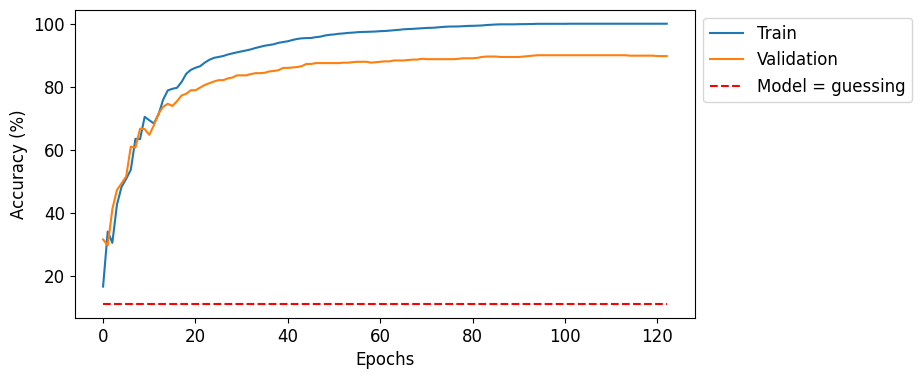

In [7]:
plt.plot(epochs_list, train_accs, label = 'Train')
plt.plot(epochs_list, val_accs, label = 'Validation')
plt.hlines(100/9, 0, epochs_list[-1], linestyles='--', color ='red', label = 'Model = guessing')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

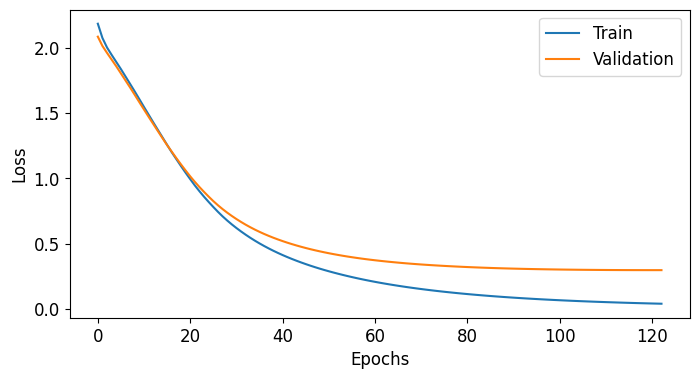

In [8]:
plt.plot(epochs_list, train_losses, label = 'Train')
plt.plot(epochs_list, val_losses, label = 'Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

 Linear combination -- check if model works

In [9]:
def data_creation_mixed_spectra(noise_level_):
    '''This function outputs a noisy absorption spectrum, normalized with mean and standard deviation.'''
    mixture_spectra_full, weights_spectra = generate_mixture_spectra(df, combination_sizes = (8,9))
    mixture_spectra_full = mixture_spectra_full.to_numpy()

    weight_values = weights_spectra.drop(columns="mixture_name").to_numpy(dtype=float) # shape (600,9) (samples, species)
    mixture_spectra = mixture_spectra_full[:,10:].astype(float).T # shape (600, 451)(samples, wavelengths)
    number_of_samples, _ = mixture_spectra.shape
    
    X = torch.tensor(mixture_spectra, dtype=torch.float32) + noise_level_ * torch.randn(mixture_spectra.shape)
    y = torch.tensor(weight_values, dtype = torch.float32)

    perm = torch.randperm(X.shape[0])

    X, y = X[perm], y[perm]

    # separate into training and validation data
    N_training = int(number_of_samples * .8)
    # N_validation = int(number_of_samples * .2)

    # compute stats on training portion only
    mean = X[:N_training].mean(dim=0)
    std  = X[:N_training].std(dim=0) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets
    X_train_, y_train_ = X_norm[:N_training],  y[:N_training]
    X_val_,   y_val_   = X_norm[N_training:],  y[N_training:]
    return X_train_, y_train_, X_val_, y_val_

In [10]:
accuracy_list = []
for _ in range(1000):
    X_comb_spectra, y_comb_spectra, _, _ = data_creation_mixed_spectra(noise_level)

    pred_comb = trained_model(X_comb_spectra).squeeze()
    prob_comb = nn.Softmax(dim=1)(pred_comb)
    nr_spectra, _ = X_comb_spectra.shape

    pred_top2 = torch.topk(prob_comb, k=2, dim=1)
    actual_top2 = torch.topk(y_comb_spectra, k = 2, dim = 1)

    pred_first_max = pred_top2.indices[:, 0]  # index of first highest
    actual_first_max = actual_top2.indices[:,0]

    accuracy_first = (pred_first_max == actual_first_max).float().mean().item() * 100
    accuracy_list.append(accuracy_first)
    
print(np.mean(accuracy_list), np.std(accuracy_list))

21.4600000500679 4.902132213157016


In [11]:

pred_all = torch.topk(prob_comb, k = 9, dim = 1)
actual_all = torch.topk(y_comb_spectra, k = 9, dim = 1)
# checks if whole list is in correct order
print(pred_all.indices[0])
print(pred_all.values[0])

accuracy = (pred_all.indices == actual_all.indices).float().mean().item() * 100
print(accuracy)
print(f'Random guess:{100/9}')

tensor([4, 6, 1, 5, 8, 2, 7, 0, 3])
tensor([9.9890e-01, 9.5768e-04, 1.3484e-04, 7.7176e-06, 1.1963e-06, 3.8253e-08,
        1.0972e-08, 9.5759e-09, 8.2903e-09], grad_fn=<SelectBackward0>)
14.722222089767456
Random guess:11.11111111111111
